# li2026 energy-storage-station cells

This notebook lists the 90 released battery groups, loads one eight-cell group, and plots one cell voltage. It makes no diagnosis.

## 1. Released units

This step lists what `systems('li2026')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('li2026')
display(released)

,unit,period,battery,first_cell,last_cell,samples,files
0,real_world_02-03/battery_01,real_world_02-03,1,1,8,31960,8
1,real_world_02-03/battery_02,real_world_02-03,2,9,16,31960,8
2,real_world_02-03/battery_03,real_world_02-03,3,17,24,31960,8
3,real_world_02-03/battery_04,real_world_02-03,4,25,32,31960,8
4,real_world_02-03/battery_05,real_world_02-03,5,33,40,31960,8
...,...,...,...,...,...,...,...
85,real_world_05_06/battery_26,real_world_05_06,26,201,208,9780,3
86,real_world_05_06/battery_27,real_world_05_06,27,209,216,9780,3
87,real_world_05_06/battery_28,real_world_05_06,28,217,224,9780,3
88,real_world_05_06/battery_29,real_world_05_06,29,225,232,9780,3


Each row is one eight-cell group in one of three recording periods. There are 240 numbered cells, while the paper describes 200.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('li2026', unit='real_world_02-03/battery_01')
print(frame.shape)
display(frame.head())

(31960, 18)


,cell_001_V,cell_002_V,cell_003_V,cell_004_V,cell_005_V,cell_006_V,cell_007_V,cell_008_V,cell_001_T,cell_002_T,cell_003_T,cell_004_T,cell_005_T,cell_006_T,cell_007_T,cell_008_T,cur,unit
sample,,,,,,,,,,,,,,,,,,
0,3.208,3.208,3.208,3.208,3.207,3.208,3.208,3.208,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,0.000000,real_world_02-03/battery_01
1,3.223,3.223,3.223,3.223,3.222,3.223,3.224,3.224,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,-43.899902,real_world_02-03/battery_01
2,3.224,3.225,3.224,3.225,3.224,3.225,3.226,3.225,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,-45.599854,real_world_02-03/battery_01
3,3.227,3.227,3.227,3.227,3.227,3.227,3.228,3.228,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,-44.699950,real_world_02-03/battery_01
4,3.228,3.228,3.228,3.228,3.228,3.229,3.229,3.229,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,-43.899902,real_world_02-03/battery_01


The group's files are joined in sample order. The release has no calendar timestamps, so the index is the sample number from the file names.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['cell_001_V', 'cell_008_V', 'cell_001_T', 'cur']].describe().T)

,count,mean,std,min,25%,50%,75%,max
cell_001_V,31960.0,3.315239,0.062556,3.13100,3.268,3.332000,3.37200,3.43600
cell_008_V,31960.0,3.316274,0.066009,3.12900,3.266,3.333000,3.37300,3.60400
cell_001_T,31960.0,33.476001,3.661477,28.00000,30.000,32.000000,36.00000,42.00000
cur,31960.0,0.001623,89.618654,-133.19995,-43.500,-41.899902,116.19995,141.40015


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

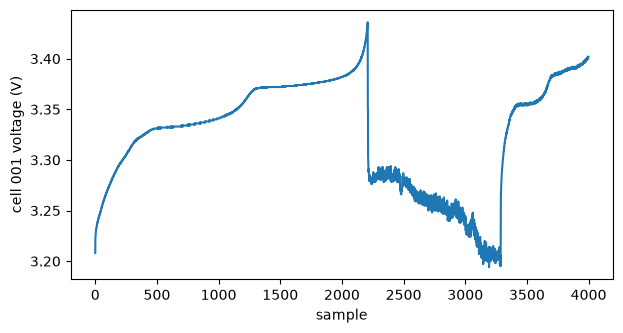

In [4]:
ax = frame['cell_001_V'].iloc[:4000].plot(figsize=(7, 3.5))
ax.set_xlabel('sample')
ax.set_ylabel('cell 001 voltage (V)')
plt.show()

Over the first 4,000 samples cell 001 charges, discharges and charges again, with the flat plateaus of an LFP cell.